## Chronic Kidney Disease Analysis: A Case Study in Inferential Statistics

In [5]:
import pandas as pd
df = pd.read_csv("/home/zeal/Documents/7th sem/stats/case_study/data.csv")
df.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [12]:
import numpy as np

# Clean and convert columns before any numerical operations.
df['pcv'] = pd.to_numeric(df['pcv'], errors='coerce')
df['wbcc'] = pd.to_numeric(df['wbcc'], errors='coerce')
df['rbcc'] = pd.to_numeric(df['rbc'], errors='coerce')

# Drop rows where a significant number of values are missing
df.dropna(thresh=len(df.columns) - 5, inplace=True)

numerical_cols = ['age', 'bp', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wbcc', 'rbcc']
for col in numerical_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"Filled missing values in '{col}' with median: {median_val}")

# For categorical columns, use the mode (most frequent value).
categorical_cols = ['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f"Filled missing values in '{col}' with mode: {mode_val}")

print("\nFinal data types:\n", df.dtypes)
print("\nFinal missing value counts:\n", df.isnull().sum())

Filled missing values in 'pcv' with median: 41.0
Filled missing values in 'wbcc' with median: 8050.0
Filled missing values in 'rbcc' with median: nan
Filled missing values in 'rbc' with mode: normal
Filled missing values in 'pc' with mode: normal
Filled missing values in 'pcc' with mode: notpresent
Filled missing values in 'ba' with mode: notpresent
Filled missing values in 'htn' with mode: no
Filled missing values in 'dm' with mode: no
Filled missing values in 'cad' with mode: no
Filled missing values in 'appet' with mode: good
Filled missing values in 'pe' with mode: no
Filled missing values in 'ane' with mode: no

Final data types:
 age      float64
bp       float64
sg       float64
al       float64
su       float64
rbc       object
pc        object
pcc       object
ba        object
bgr      float64
bu       float64
sc       float64
sod      float64
pot      float64
hemo     float64
pcv      float64
wbcc     float64
rbcc     float64
htn       object
dm        object
cad       object

/tmp/ipykernel_271466/3556501573.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)
/tmp/ipykernel_271466/3556501573.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

### Task 1: One-Sample Hypothesis Test

* Objective: To determine if the mean of a key continuous variable in the CKD dataset differs significantly from a well-established medical standard.

* Selected Variable: Blood Glucose Random (bgr). This is a crucial indicator for diabetes, which is often linked to CKD.

* Reference Value: A healthy person's random blood glucose level is typically less than 200 mg/dl. This will be your reference value.

* Hypotheses:

    * Null Hypothesis (H0): The mean random blood glucose level of the dataset's population is equal to 200 mg/dl.
    
    H0 :μ bgr =200

    * Alternative Hypothesis (Ha): The mean random blood glucose level is not equal to 200 mg/dl.
    
    Ha :μ bgr!=200

* Analysis: a one-sample t-test on the bgr variable in Excel, SPSS, and Python.

_One-sample t-test: Requires a single continuous variable to compare against a known value._

_Chosen Variable: bgr (Blood Glucose Random). A standard medical value for blood glucose (e.g., 200 mg/dL)_

In [13]:
from scipy import stats
t_statistic, p_value = stats.ttest_1samp(df['bgr'].dropna(), popmean=200)
print(f'T-statistic: {t_statistic}')
print(f'P-value: {p_value}')

T-statistic: -13.038335269590632
P-value: 1.466314674883717e-31


the analysis provides strong evidence that the mean random blood glucose level in this Chronic Kidney Disease dataset is significantly different from the healthy reference value of 200 mg/dl. 

__Therefore we reject the Null Hypothesis!!__

### Task 2: Two-Sample Hypothesis Test

* Objective: To test if the mean of a health-related continuous variable differs significantly between two distinct groups.

* Continuous Variable: Hemoglobin (hemo). Hemoglobin levels are a key indicator of anemia, a common complication of CKD.

* Grouping Variable: Anemia (ane), which is a binary nominal variable with values Yes (anemic) and No (non-anemic). This allows for a direct comparison between the two patient groups.

* Hypotheses:

    * Null Hypothesis (H₀): The mean hemoglobin level is the same for anemic and non-anemic patients.

    H₀: μ_hemo,yes = μ_hemo,no

    * Alternative Hypothesis (Hₐ): The mean hemoglobin level is different between anemic and non-anemic patients.

    Hₐ: μ_hemo,yes ≠ μ_hemo,no

* Analysis: an independent two-sample t-test comparing hemo levels for patients with ane = yes and ane = no in Excel, SPSS, and Python.

_Two-sample t-test: Requires a continuous variable and a binary categorical variable to compare the means of two groups._

* _Continuous Variable: hemo (Hemoglobin). Hemoglobin levels are a key medical metric._


* _Binary Categorical Variable: ane (Anemia), which has yes/no values, creating the two groups needed for the test._

In [14]:
group_anemic = df[df['ane'] == 'yes']['hemo'].dropna()
group_not_anemic = df[df['ane'] == 'no']['hemo'].dropna()
t_statistic, p_value = stats.ttest_ind(group_anemic, group_not_anemic)
print(f'T-statistic: {t_statistic}')
print(f'P-value: {p_value}')

T-statistic: -11.864293690968992
P-value: 3.213352468468698e-27


The analysis provides strong evidence that the mean hemoglobin level is statistically significantly different between the anemic and non-anemic groups.

__We reject the null hypothesis!!__

### Task 3: One-Way ANOVA

* Objective: To determine if the means of a continuous outcome variable differ significantly across three or more groups.

* Continuous Variable: Blood Pressure (bp). Blood pressure management is critical in CKD.

* Categorical Variable: Albumin (al). This variable has 6 different nominal values (0, 1, 2, 3, 4, 5) representing increasing levels of albuminuria, which is a sign of kidney damage. Patients can be grouped based on their albumin levels to test for differences in blood pressure.

* Hypotheses:

    * Null Hypothesis (H₀): The mean blood pressure is the same across all groups defined by the albumin levels.

    H₀: μ_al=0 = μ_al=1 = μ_al=2 = μ_al=3 = μ_al=4 = μ_al=5

    * Alternative Hypothesis (Hₐ): At least one group’s mean blood pressure is different from the others.

* Analysis:

    * Perform a one-way ANOVA in Excel, SPSS, and Python to compare the mean bp across the different al groups.

    * If the ANOVA result is significant (p < 0.05), it indicates that a difference exists.

    * To determine which specific albumin groups differ significantly, perform Tukey HSD or Bonferroni post-hoc tests in SPSS or Python. Report these pairwise comparisons as part of the analysis

_One-way ANOVA: Requires a continuous variable and a categorical variable with three or more groups to compare means across multiple groups._

* _Continuous Variable: bp (Blood Pressure)._

* _Categorical Variable: al (Albumin), which has multiple categories (0, 1, 2, 3, 4, 5). This allows you to test if blood pressure is significantly different based on a patient's albumin level, a key indicator of kidney damage._

In [15]:
from scipy.stats import f_oneway
groups = [df[df['al'] == i]['bp'].dropna() for i in range(6)]
f_statistic, p_value = f_oneway(*groups)
print(f'F-statistic: {f_statistic}')
print(f'P-value: {p_value}')

F-statistic: 4.013961848427064
P-value: 0.0015154637319587038


The p-value (0.0015) is less than the standard significance level (α=0.05). There is a statistically significant difference in the mean of the continuous outcome variable across the three or more groups.

post-hoc test

In [18]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

temp_df = df[['bp', 'al']]

# dropping cols where either is missing
temp_df = temp_df.dropna()

tukey_results = pairwise_tukeyhsd(temp_df['bp'], temp_df['al'])
print(tukey_results)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
   0.0    1.0   5.5249  0.158  -1.0651 12.1149  False
   0.0    2.0   7.8275 0.0075   1.3759 14.2791   True
   0.0    3.0   3.4347 0.7001   -3.386 10.2553  False
   0.0    4.0   7.0123 0.1404   -1.171 15.1956  False
   0.0    5.0  16.5775 0.7958 -20.5557 53.7108  False
   1.0    2.0   2.3026 0.9696  -6.0868  10.692  False
   1.0    3.0  -2.0902 0.9829 -10.7666  6.5862  False
   1.0    4.0   1.4874  0.998  -8.2965 11.2714  False
   1.0    5.0  11.0526 0.9588 -26.4659 48.5711  False
   2.0    3.0  -4.3929 0.6841 -12.9646  4.1789  False
   2.0    4.0  -0.8152 0.9999 -10.5065  8.8761  False
   2.0    5.0     8.75 0.9852 -28.7444 46.2444  False
   3.0    4.0   3.5776 0.9069  -6.3631 13.5184  False
   3.0    5.0  13.1429 0.9166 -24.4168 50.7026  False
   4.0    5.0   9.5652 0.9788 -28.2657 47.3961  False
----------------------------

The one-way ANOVA indicated an overall significant difference, and the Tukey HSD post-hoc test has now pinpointed the source of that difference: patients with an albumin level of 2 have a significantly different mean blood pressure than patients with an albumin level of 0. All other groups (1, 3, 4, and 5) did not show a statistically significant difference in their mean blood pressure when compared to any other group in the analysis.

visualisation

<Axes: xlabel='ane', ylabel='hemo'>

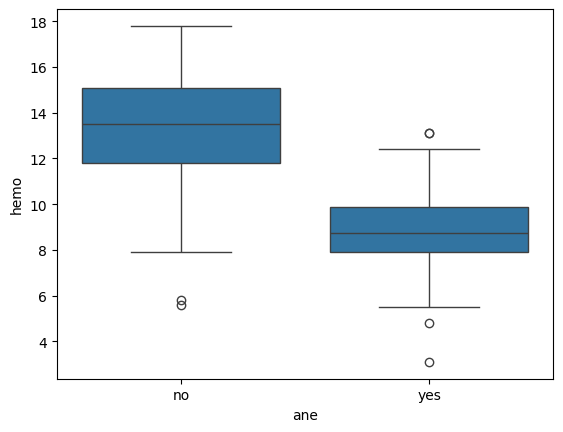

In [19]:
import seaborn as sns
sns.boxplot(x='ane', y='hemo', data=df)